# An Ablation Study of QRC for Satellite Image Denoising — Analysis (§III–§IV)

Loads the per-image metric arrays saved by `01_pipeline.ipynb` (`results/`, one `.npz`
per σ — committed, so this notebook runs without a GPU) and reproduces every number,
table and figure of the paper's results and discussion, plus supporting detail stated
only in prose: exact p-values, full bootstrap distributions, medians, and percentile
spreads of the paired differences.

In [1]:
import numpy as np
from pathlib import Path
from scipy.stats import ttest_1samp, wilcoxon, binomtest, norm

from src import plots
from src.plots import LABELS, BETTER

SEED    = 42
D_QRC   = 18
SIGMAS  = [0.1, 0.3, 0.5, 0.7]
METRICS = ["mse", "ssim", "teng"]

RESULTS_DIR = Path("results")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

runs = {}
for s in SIGMAS:
    p = RESULTS_DIR / f"sigma{s}_per_image_metrics_d{D_QRC}.npz"
    assert p.exists(), f"missing {p} — run 01_pipeline.ipynb with QRC_SIGMA={s}"
    runs[s] = np.load(p)
    print(f"loaded σ={s}: n = {len(runs[s]['mse_hybrid'])}")

# Paired per-image differences, hybrid − baseline
delta = {(m, s): runs[s][f"{m}_hybrid"] - runs[s][f"{m}_baseline"]
         for m in METRICS for s in SIGMAS}

loaded σ=0.1: n = 2700
loaded σ=0.3: n = 2700
loaded σ=0.5: n = 2700
loaded σ=0.7: n = 2700


### Statistical inference (paper §II.C)

For each (metric, σ) we test $H_0$: zero mean paired difference across the test set
($n = 2700$) with a **paired t-test** — it requires only that the sampling distribution
of the mean be approximately normal, justified by the CLT at this $n$. This is
complemented with a **95% bootstrap confidence interval** (10 000 resamples) on the mean
and on the median, and with the **Wilcoxon signed-rank** and **sign tests**, none of
which assume normality. Significance is assessed at the $\alpha = 0.05$ level.
p-values below float64 resolution are recovered in log-space from the test statistic.

In [2]:
def bootstrap_stat(measurements, stat=np.mean, n_bootstrap=10_000, seed=SEED):
    """Bootstrap distribution of an arbitrary statistic (np.mean, np.median, ...)."""
    rng = np.random.default_rng(seed)
    n = len(measurements)
    resamples = rng.choice(measurements, size=(n_bootstrap, n), replace=True)
    return stat(resamples, axis=1)


def fmt_p(p, z=None):
    """Format a p-value; on float64 underflow, recover its order of magnitude from z."""
    if p > 0:
        return f"{p:.2e}"
    if z is not None:
        log10_p = (norm.logsf(abs(z)) + np.log(2)) / np.log(10)
        return f"<1e{log10_p:.0f}"
    return "<5e-324"


def paired_stats(d):
    """Mean/median with bootstrap CIs + the three paired tests, for one delta array."""
    lo, hi = np.percentile(bootstrap_stat(d, np.mean), [2.5, 97.5])
    med_lo, med_hi = np.percentile(bootstrap_stat(d, np.median), [2.5, 97.5])
    t = ttest_1samp(d, 0.0)
    w = wilcoxon(d, method="approx")
    n_pos, n_tot = int((d > 0).sum()), int((d != 0).sum())
    s = binomtest(n_pos, n_tot, 0.5)
    return {
        "mean": d.mean(), "median": np.median(d), "std": d.std(),
        "ci": (lo, hi),
        "ci_med": (med_lo, med_hi),
        "p_t": fmt_p(t.pvalue, t.statistic),
        "p_w": fmt_p(w.pvalue, w.zstatistic),
        "p_s": fmt_p(s.pvalue),
        "win_pct": 100 * n_pos / n_tot,   # % of images where delta > 0
    }


stats = {m: {s: paired_stats(delta[(m, s)]) for s in SIGMAS} for m in METRICS}
print("stats computed for", [(m, s) for m in METRICS for s in SIGMAS])

stats computed for [('mse', 0.1), ('mse', 0.3), ('mse', 0.5), ('mse', 0.7), ('ssim', 0.1), ('ssim', 0.3), ('ssim', 0.5), ('ssim', 0.7), ('teng', 0.1), ('teng', 0.3), ('teng', 0.5), ('teng', 0.7)]


## III. Results

Full paired statistics per (metric, σ). The paper reports these compactly ("all three
tests reject $H_0$ for ΔMSE and ΔSSIM at every noise level, with $p < 10^{-3}$
throughout") — exact values below. "win %" = share of test images where the **hybrid**
is better (direction-corrected per metric).

In [3]:
for m in METRICS:
    print(f"\nΔ{m.upper()} (hybrid − baseline)   [{BETTER[m]} → hybrid better]")
    header = (f"{'σ':>5}{'mean':>12}{'95% CI (mean)':>26}{'median':>12}"
              f"{'95% CI (median)':>26}{'p (t)':>10}{'p (W)':>10}{'p (sign)':>10}{'win %':>8}")
    print(header)
    print("-" * len(header))
    for s in SIGMAS:
        st = stats[m][s]
        ci  = f"[{st['ci'][0]:+.6f}, {st['ci'][1]:+.6f}]"
        cim = f"[{st['ci_med'][0]:+.6f}, {st['ci_med'][1]:+.6f}]"
        win = 100 - st["win_pct"] if BETTER[m] == "< 0" else st["win_pct"]
        print(f"{s:>5}{st['mean']:>+12.6f}{ci:>26}{st['median']:>+12.6f}{cim:>26}"
              f"{st['p_t']:>10}{st['p_w']:>10}{st['p_s']:>10}{win:>8.1f}")


ΔMSE (hybrid − baseline)   [< 0 → hybrid better]
    σ        mean             95% CI (mean)      median           95% CI (median)     p (t)     p (W)  p (sign)   win %
-----------------------------------------------------------------------------------------------------------------------
  0.1   +0.000255    [+0.000232, +0.000279]   +0.000102    [+0.000094, +0.000109]   <1e-101   <1e-344   <5e-324    10.6
  0.3   +0.000260    [+0.000239, +0.000285]   +0.000104    [+0.000097, +0.000112]   <1e-109   <1e-342   <5e-324    11.3
  0.5   +0.000258    [+0.000236, +0.000280]   +0.000111    [+0.000101, +0.000119]   <1e-120   <1e-266 1.42e-253    18.5
  0.7   +0.000288    [+0.000266, +0.000310]   +0.000129    [+0.000118, +0.000142]   <1e-150   <1e-248 2.87e-209    21.2

ΔSSIM (hybrid − baseline)   [> 0 → hybrid better]
    σ        mean             95% CI (mean)      median           95% CI (median)     p (t)     p (W)  p (sign)   win %
-----------------------------------------------------------

### Paper claims, checked explicitly (§III)

In [4]:
for m in ("mse", "ssim"):
    excl = all(not (stats[m][s]["ci"][0] <= 0 <= stats[m][s]["ci"][1]) for s in SIGMAS)
    print(f"Δ{m.upper()}: all 95% CIs exclude zero at every σ → {excl}")

st = stats["teng"][0.3]
print("\nΔTENG at σ = 0.3 — the exception:")
print(f"  mean   {st['mean']:+.6f}  (positive — favors the hybrid)")
print(f"  median {st['median']:+.6f}  (negative — favors the baseline)")
print(f"  sign test p = {st['p_s']}  (baseline sharper on the majority of images)")
print(f"  Wilcoxon  p = {st['p_w']}  (the only test failing at α = 0.05)")
print("  → mean opposing median in sign = heavy-tailed difference distribution;")
print("    a small set of outlier images drives the positive mean (see histograms below).")

ΔMSE: all 95% CIs exclude zero at every σ → True
ΔSSIM: all 95% CIs exclude zero at every σ → True

ΔTENG at σ = 0.3 — the exception:
  mean   +0.001352  (positive — favors the hybrid)
  median -0.000282  (negative — favors the baseline)
  sign test p = 7.83e-12  (baseline sharper on the majority of images)
  Wilcoxon  p = 4.17e-01  (the only test failing at α = 0.05)
  → mean opposing median in sign = heavy-tailed difference distribution;
    a small set of outlier images drives the positive mean (see histograms below).


**Relative difference of test-set means.** The paper states the σ = 0.7 case ("MSE
differs by 6% and SSIM by less than 1%"); the full table generalizes it. Negative MSE % = hybrid
better; positive SSIM/TENG % = hybrid better.

In [5]:
print(f"{'σ':>5}" + "".join(f"{m.upper():>10}" for m in METRICS))
print("-" * 35)
for s in SIGMAS:
    rel = []
    for m in METRICS:
        mh, mb = runs[s][f"{m}_hybrid"].mean(), runs[s][f"{m}_baseline"].mean()
        rel.append(100 * (mh - mb) / mb)
    print(f"{s:>5}" + "".join(f"{r:>+9.2f}%" for r in rel))

    σ       MSE      SSIM      TENG
-----------------------------------
  0.1    +5.54%    -0.52%    -1.93%
  0.3    +5.59%    -0.64%    +5.66%
  0.5    +5.36%    -0.36%   -12.76%
  0.7    +5.79%    -0.53%    -3.32%


**Percentile spread of the paired differences.** Not in the paper, but the basis of
its heavy-tail argument: for ΔTENG at σ = 0.3 the bulk of the distribution (p25–p75) is
negative while the mean is positive.

In [6]:
qs = [5, 25, 50, 75, 95]
for m in METRICS:
    print(f"\nΔ{m.upper()} percentiles   [{BETTER[m]} → hybrid better]")
    print(f"{'σ':>5}" + "".join(f"{f'p{q}':>12}" for q in qs))
    print("-" * 65)
    for s in SIGMAS:
        pct = np.percentile(delta[(m, s)], qs)
        print(f"{s:>5}" + "".join(f"{v:>+12.6f}" for v in pct))


ΔMSE percentiles   [< 0 → hybrid better]
    σ          p5         p25         p50         p75         p95
-----------------------------------------------------------------
  0.1   -0.000041   +0.000033   +0.000102   +0.000271   +0.000881
  0.3   -0.000040   +0.000032   +0.000104   +0.000292   +0.000974
  0.5   -0.000112   +0.000023   +0.000111   +0.000334   +0.000956
  0.7   -0.000141   +0.000015   +0.000129   +0.000409   +0.001029

ΔSSIM percentiles   [> 0 → hybrid better]
    σ          p5         p25         p50         p75         p95
-----------------------------------------------------------------
  0.1   -0.014755   -0.004755   -0.001934   +0.000213   +0.005000
  0.3   -0.019486   -0.005382   -0.001908   +0.000314   +0.004391
  0.5   -0.013372   -0.004475   -0.001493   +0.000716   +0.006235
  0.7   -0.015172   -0.005457   -0.002063   +0.000539   +0.004864

ΔTENG percentiles   [> 0 → hybrid better]
    σ          p5         p25         p50         p75         p95
--------------

### Fig. 1 — mean paired difference per metric across noise levels

Error bars: 95% bootstrap CIs (narrow — SE ~ std/√2700, often smaller than the marker).
A bar not crossing zero = significant difference at that σ.

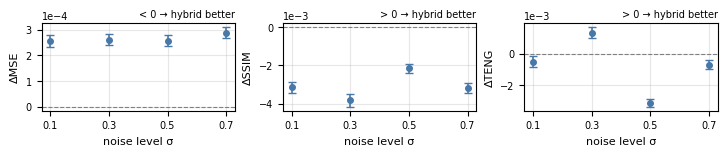

saved figures/delta_vs_sigma.pdf (+ .png preview)


In [7]:
plots.fig_delta_vs_sigma(stats, SIGMAS, METRICS, FIG_DIR)

### Distributions behind the means

Per-image paired-difference histograms (population spread, heavy ΔTENG tail visible)
and the full bootstrap distributions of the mean (10 000 resamples, the paper's CI
machinery shown in full).

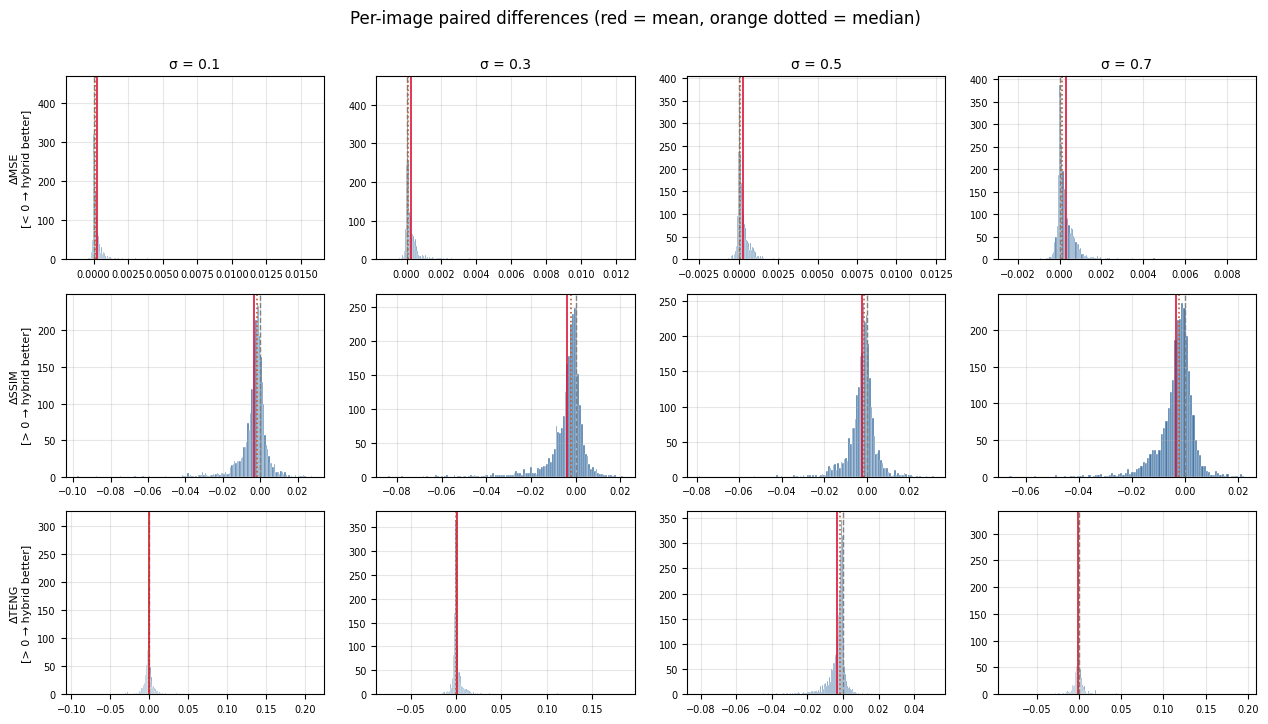

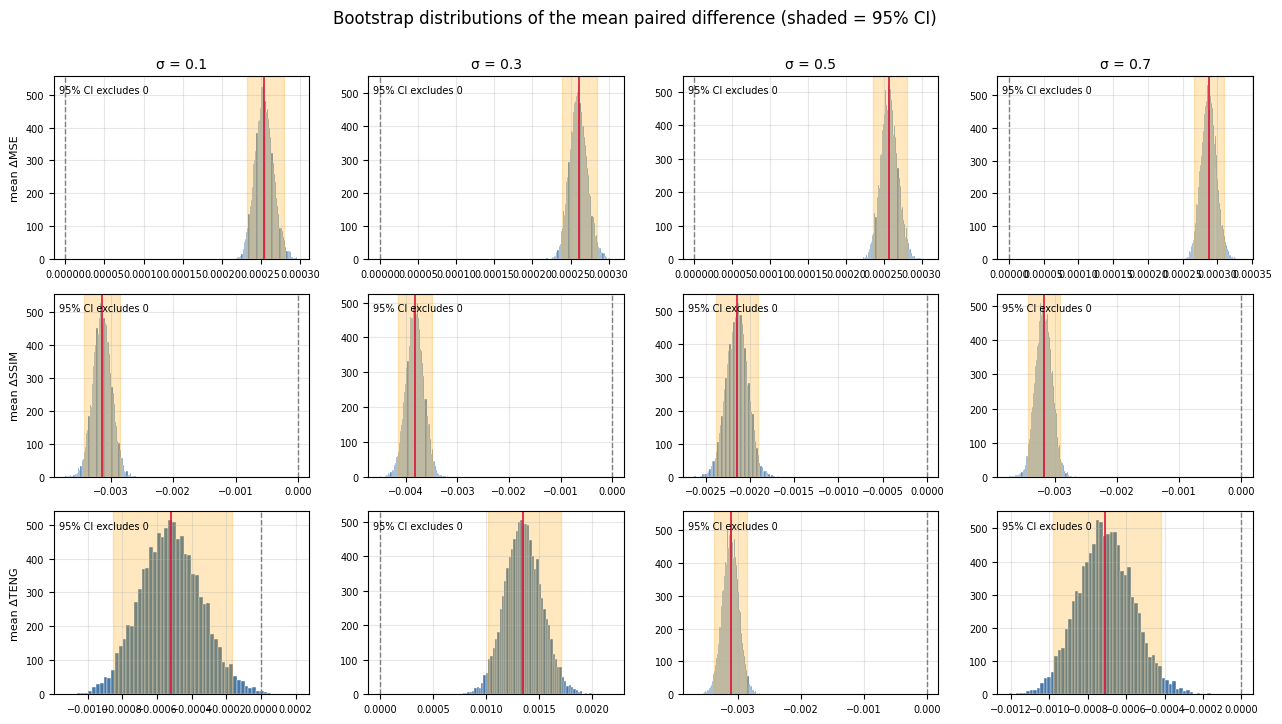

In [8]:
plots.delta_hist_grid(delta, SIGMAS, METRICS)

boots = {k: bootstrap_stat(v, np.mean) for k, v in delta.items()}
plots.bootstrap_grid(boots, delta, SIGMAS, METRICS)

### Mean vs median and win rates (supporting views)

Mean and median diverging in sign (ΔTENG, σ = 0.3) = outlier-dominated mean. Win rate
shows the baseline winning on the majority of images for every metric and σ.

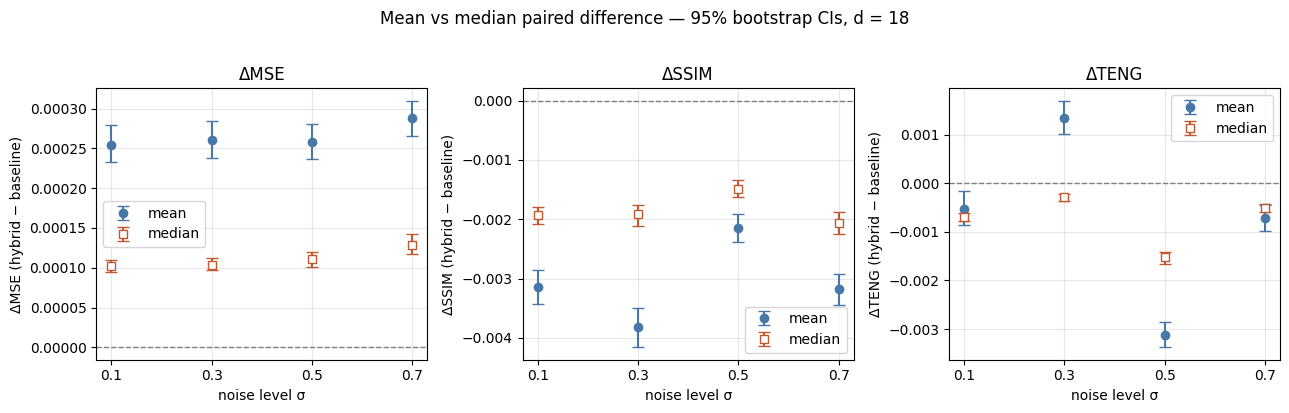

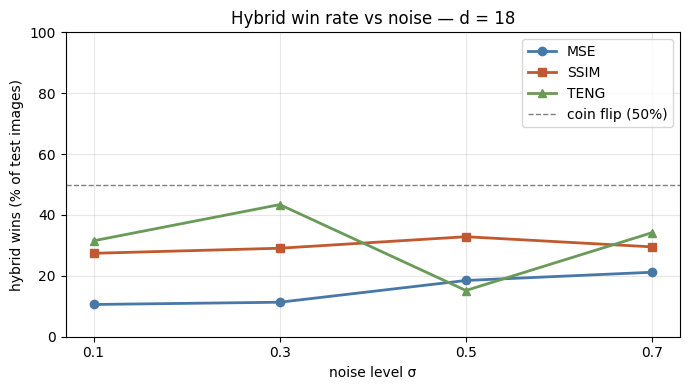

In [9]:
plots.mean_vs_median(stats, SIGMAS, METRICS, D_QRC)
plots.win_rate(stats, SIGMAS, METRICS, D_QRC)

### Fig. 2 — qualitative reconstruction across noise levels

One texture-rich test image across all σ. Clean shown once (left); rows follow the
pipeline: PCA(18) linear projection → baseline MLP → hybrid QRC. The PCA-projection row
already shows the smoothing seen in both reconstructions — the dimensionality
bottleneck, not the readout, limits quality.

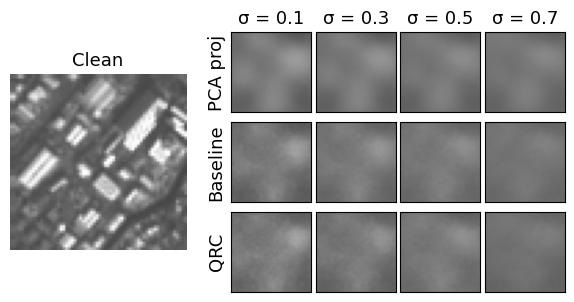

saved figures/qualitative_vs_sigma.pdf (+ .png preview)

Showcase image SSIM (paper Fig. 2 caption: 0.12–0.14 for all methods and σ, far below the test-set mean ≈ 0.6):
    σ  PCA proj  baseline    hybrid  test-set mean (hybrid)
-----------------------------------------------------------
  0.1     0.136     0.133     0.131                   0.598
  0.3     0.135     0.131     0.128                   0.598
  0.5     0.134     0.126     0.125                   0.597
  0.7     0.132     0.124     0.125                   0.595


In [10]:
plots.fig_qualitative(runs, SIGMAS, FIG_DIR)

print("\nShowcase image SSIM (paper Fig. 2 caption: 0.12–0.14 for all methods and σ,"
      " far below the test-set mean ≈ 0.6):")
print(f"{'σ':>5}{'PCA proj':>10}{'baseline':>10}{'hybrid':>10}{'test-set mean (hybrid)':>24}")
print("-" * 59)
for s in SIGMAS:
    r = runs[s]
    print(f"{s:>5}{float(r['showcase_ssim_pca']):>10.3f}"
          f"{float(r['showcase_ssim_baseline']):>10.3f}"
          f"{float(r['showcase_ssim_hybrid']):>10.3f}"
          f"{r['ssim_hybrid'].mean():>24.3f}")

## IV. Discussion

Reconstruction quality of both pipelines is limited by the dimensionality bottleneck of
classical reservoir simulation: $d = 18$ linear components carry the entire spatial
content of each 64×64 image, and the reservoir embedding is a fixed nonlinear expansion
of those same components — it can at best preserve their information content, and in
practice loses a small amount (consistent with the baseline's small but significant
advantage).

The TENG instability follows from the same smoothing: TENG aggregates only squared
gradients above a threshold, and in blurred reconstructions the metric is decided by
the few pixels that cross it. EuroSAT's variance also concentrates heavily on PC1
(≈ brightness), so both readouts recover global lighting while failing on spatial
texture, which the cut excluded. Both effects are quantified below.

In [11]:
print("TENG recovered as a fraction of the clean images' TENG"
      " (paper §IV: both models recover at most 4.1%):")
print(f"{'σ':>5}{'hybrid':>10}{'baseline':>10}")
print("-" * 25)
for s in SIGMAS:
    r = runs[s]
    tc = r["teng_clean"].mean()
    print(f"{s:>5}{100 * r['teng_hybrid'].mean() / tc:>9.2f}%"
          f"{100 * r['teng_baseline'].mean() / tc:>9.2f}%")

evr = runs[SIGMAS[0]]["pca_evr"]
print(f"\nPC1 explained variance:   {100 * evr[0]:.2f}%  (paper §IV: 66.91%)")
print(f"PCs 1–{D_QRC} cumulative:     {100 * evr[:D_QRC].sum():.2f}%")

# PC1 ≈ brightness (paper §IV) — quantitative justification, computed in 01
r0 = runs[SIGMAS[0]]
print(f"\ncorr(PC1, mean brightness), clean train:  |r| = {abs(float(r0['pc1_brightness_r'])):.4f}")
print(f"cos(PC1 loading, uniform direction):      |cos| = {abs(float(r0['pc1_uniform_cos'])):.4f}")
print("corr(PC1, mean brightness) on noisy test projections:")
for s in SIGMAS:
    print(f"  σ = {s}:  |r| = {abs(float(runs[s]['pc1_brightness_r_noisy'])):.4f}")

TENG recovered as a fraction of the clean images' TENG (paper §IV: both models recover at most 4.1%):
    σ    hybrid  baseline
-------------------------
  0.1     3.97%     4.05%
  0.3     3.79%     3.58%
  0.5     3.20%     3.67%
  0.7     3.09%     3.20%

PC1 explained variance:   66.91%  (paper §IV: 66.91%)
PCs 1–18 cumulative:     81.08%

corr(PC1, mean brightness), clean train:  |r| = 1.0000
cos(PC1 loading, uniform direction):      |cos| = 0.9994
corr(PC1, mean brightness) on noisy test projections:
  σ = 0.1:  |r| = 1.0000
  σ = 0.3:  |r| = 1.0000
  σ = 0.5:  |r| = 1.0000
  σ = 0.7:  |r| = 1.0000


**Future work** (paper §IV): normalize the first principal component before
encoding, removing the dominant brightness shortcut (this only shifts the encoded set
to components 2–19, still leaving most texture unencoded); replace the MLP readout with
a spatial-aware network — a transposed-convolution decoder or a U-Net expansive path —
to upsample the embeddings into a coherent spatial topology; and address the bottleneck
itself with larger reservoirs or encodings that do not route all spatial information
through a global PCA.